In [1]:
import pybamm
import matplotlib.pyplot as plt

In [11]:
parameter_values.search("SEI")

Initial inner SEI thickness [m]	2.5e-09
Initial outer SEI thickness [m]	2.5e-09
Inner SEI electron conductivity [S.m-1]	8.95e-14
Inner SEI lithium interstitial diffusivity [m2.s-1]	1e-20
Inner SEI open-circuit potential [V]	0.1
Inner SEI partial molar volume [m3.mol-1]	9.585e-05
Inner SEI reaction proportion	0.5
Outer SEI open-circuit potential [V]	0.8
Outer SEI partial molar volume [m3.mol-1]	9.585e-05
Outer SEI solvent diffusivity [m2.s-1]	2.5000000000000002e-22
Ratio of lithium moles to SEI moles	2.0
SEI growth activation energy [J.mol-1]	0.0
SEI kinetic rate constant [m.s-1]	1e-12
SEI open-circuit potential [V]	0.4
SEI reaction exchange current density [A.m-2]	1.5e-07
SEI resistivity [Ohm.m]	200000.0


In [12]:
model = pybamm.lithium_ion.SPM({"SEI": "ec reaction limited"})
parameter_values = pybamm.ParameterValues("Mohtat2020")
parameter_values.update({"SEI kinetic rate constant [m.s-1]": 1e-13})


def cycle(c_rate):
    return [
        (
            pybamm.step.c_rate(c_rate, termination="2.5V"),
            pybamm.step.c_rate(0, duration=60 * 30),
            pybamm.step.c_rate(-1, termination="4.2V"),
            pybamm.step.voltage(4.2, termination="0.05C"),
            pybamm.step.c_rate(0, duration=60 * 30),
        )
    ]


experiment = []
sols = {}
pybamm.set_logging_level("NOTICE")
for c_rate in [1 / 2, 1, 2]:
    experiment = cycle(c_rate) * 1000
    experiment = pybamm.Experiment(experiment, termination="80% capacity")
    solver = pybamm.IDAKLUSolver()
    sim = pybamm.Simulation(
        model, parameter_values=parameter_values, experiment=experiment, solver=solver
    )
    sol = sim.solve()
    sols[c_rate] = sol

2024-09-25 13:04:26.396 - [NOTICE] logger.func(7): Cycle 1/1000 (54.208 us elapsed) --------------------
2024-09-25 13:04:26.396 - [NOTICE] logger.func(7): Cycle 1/1000, step 1/5: Step(0.5, duration=14400.0, termination=[<pybamm.experiment.step.step_termination.VoltageTermination object at 0x2a26875d0>], direction=Discharge)
2024-09-25 13:04:26.423 - [NOTICE] logger.func(7): Cycle 1/1000, step 2/5: Step(0, duration=1800, direction=Rest)
2024-09-25 13:04:26.441 - [NOTICE] logger.func(7): Cycle 1/1000, step 3/5: Step(-1, duration=7200.0, termination=[<pybamm.experiment.step.step_termination.VoltageTermination object at 0x2a48b53d0>], direction=Charge)
2024-09-25 13:04:26.468 - [NOTICE] logger.func(7): Cycle 1/1000, step 4/5: Step(4.2, duration=86400, termination=[<pybamm.experiment.step.step_termination.CrateTermination object at 0x2a79aecd0>])
2024-09-25 13:04:26.503 - [NOTICE] logger.func(7): Cycle 1/1000, step 5/5: Step(0, duration=1800, direction=Rest)
2024-09-25 13:04:26.558 - [NOTI

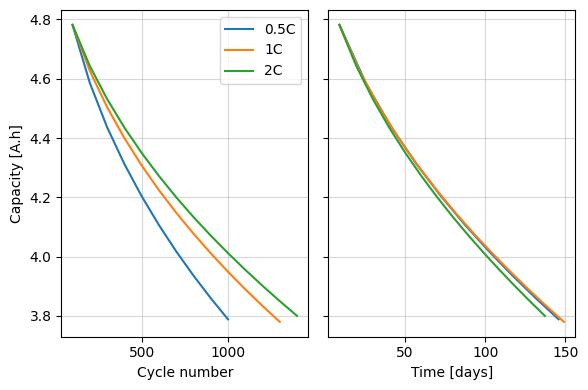

In [15]:
fig, axes = plt.subplots(1,2, figsize=(6,4),sharey=True)
for c_rate, sol in sols.items():
    cycle_numbers = sol.summary_variables["Cycle number"] * 100
    time = sol.summary_variables["Time [s]"] / 3600 / 24 * 100
    capacities = sol.summary_variables["Capacity [A.h]"]
    axes[0].plot(cycle_numbers, capacities, label=f"{c_rate}C")
    axes[1].plot(time, capacities)
axes[0].set_xlabel("Cycle number")
axes[0].set_ylabel("Capacity [A.h]")
axes[1].set_xlabel("Time [days]")
for ax in axes:
    ax.grid(alpha=0.5)
axes[0].legend()
fig.tight_layout()
plt.savefig("figures/sei-c-rate.png", dpi=300)
